In [ ]:
#   Production-style batch scoring on Kaggle cs-test.csv.

import json
import joblib
import warnings
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import statsmodels.api as sm
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

In [ ]:
# Paths

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR = OUTPUT_DIR / "saved_models"
CONFIG_DIR = OUTPUT_DIR / "model_configs"
REPORT_DIR = OUTPUT_DIR / "reports"

SCORING_HANDOFF_DIR = OUTPUT_DIR / "scoring_handoff"

BASE_MODEL_DIR = MODEL_DIR / "base_models"
ENSEMBLE_MODEL_DIR = MODEL_DIR / "ensemble_models"

BASE_CONFIG_DIR = CONFIG_DIR / "base_models"
ENSEMBLE_CONFIG_DIR = CONFIG_DIR / "ensemble_models"

print("Project Root:", PROJECT_ROOT)
print("Data Directory:", DATA_DIR)
print("Output Directory:", OUTPUT_DIR)
print("Model Directory:", MODEL_DIR)
print("Config Directory:", CONFIG_DIR)
print("Reports Directory:", REPORT_DIR)
print("Scoring Handoff Directory:", SCORING_HANDOFF_DIR)

Project Root: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab
Data Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/data
Output Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs
Model Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/saved_models
Config Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/model_configs
Reports Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/reports
Scoring Handoff Directory: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/scoring_handoff


In [ ]:
# Load Scoring Handoff Bundle

with open(SCORING_HANDOFF_DIR / "expected_columns.json", "r") as f:
    expected_columns = json.load(f)

with open(SCORING_HANDOFF_DIR / "base_model_features.json", "r") as f:
    base_model_features = json.load(f)

with open(SCORING_HANDOFF_DIR / "finalist_models.json", "r") as f:
    finalist_models = json.load(f)

ensemble_registry = joblib.load(SCORING_HANDOFF_DIR / "ensemble_registry.joblib")
model_configs = joblib.load(SCORING_HANDOFF_DIR / "model_configs.joblib")

print("Scoring handoff loaded.")
print("Finalist models:")
print(finalist_models)

Scoring handoff loaded.
Finalist models:
{'production_candidate': 'BAYSTACK004', 'auc_leader': 'BAYSTACK002', 'weighted_average_challenger': 'WASTACK003', 'nonlinear_challenger': 'XGBSTACK004', 'single_model_benchmark': 'LGB002', 'required_base_models': ['LGB002', 'CAT005', 'XGB004']}


In [ ]:
# Load Raw Test Data

test_path = DATA_DIR / "cs-test.csv"

df_test_raw = pd.read_csv(test_path)

print("Raw test shape:", df_test_raw.shape)
display(df_test_raw.head())
display(df_test_raw.info())

Raw test shape: (101503, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


<class 'pandas.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  NumberOfDep

None

In [ ]:
# Inspect Raw Test Data

print("Columns:")
print(df_test_raw.columns.tolist())

missing_summary = pd.DataFrame({
    "missing_count": df_test_raw.isna().sum(),
    "missing_pct": df_test_raw.isna().mean()
}).sort_values("missing_pct", ascending=False)

display(missing_summary)

display(df_test_raw.describe().T)

Columns:
['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


,missing_count,missing_pct
SeriousDlqin2yrs,101503,1.000000
MonthlyIncome,20103,0.198053
NumberOfDependents,2626,0.025871
Unnamed: 0,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,101503.0,50752.000000,29301.536524,1.0,25376.500000,50752.000000,76127.500000,101503.0
SeriousDlqin2yrs,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RevolvingUtilizationOfUnsecuredLines,101503.0,5.310000,196.156039,0.0,0.030131,0.152586,0.564225,21821.0
age,101503.0,52.405436,14.779756,21.0,41.000000,52.000000,63.000000,104.0
NumberOfTime30-59DaysPastDueNotWorse,101503.0,0.453770,4.538487,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,101503.0,344.475020,1632.595231,0.0,0.173423,0.364260,0.851619,268326.0
MonthlyIncome,81400.0,6855.035590,36508.600375,0.0,3408.000000,5400.000000,8200.000000,7727000.0
NumberOfOpenCreditLinesAndLoans,101503.0,8.453514,5.144100,0.0,5.000000,8.000000,11.000000,85.0
NumberOfTimes90DaysLate,101503.0,0.296691,4.515859,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,101503.0,1.013074,1.110253,0.0,0.000000,1.000000,2.000000,37.0


In [ ]:
# Preserve Applicant ID and Confirm Target Availability

ID_COL = "Unnamed: 0"
TARGET = "SeriousDlqin2yrs"

if ID_COL not in df_test_raw.columns:
    raise KeyError(f"Expected ID column not found: {ID_COL}")

applicant_id = df_test_raw[ID_COL].copy()

if TARGET in df_test_raw.columns:
    target_non_null = df_test_raw[TARGET].notna().sum()
    print(f"Non-null target rows: {target_non_null}")

    if target_non_null == 0:
        print("Target is unavailable in cs-test.csv. This is production-style scoring, not model evaluation.")
    else:
        print("Target appears partially/fully available. Check before treating this as unlabeled.")
else:
    print("Target column not found. Proceeding as unlabeled scoring dataset.")

Non-null target rows: 0
Target is unavailable in cs-test.csv. This is production-style scoring, not model evaluation.


In [ ]:
# Create Working Raw Test Frame

df_test = df_test_raw.copy()

# Drop Kaggle ID and unavailable target from feature frame
drop_cols = [c for c in [ID_COL, TARGET] if c in df_test.columns]

df_test_features_raw = df_test.drop(columns=drop_cols)

print("Raw feature frame shape:", df_test_features_raw.shape)
display(df_test_features_raw.head())

Raw feature frame shape: (101503, 10)


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [ ]:
# Inspect Available Config / Mapping Files

config_manifest_path = SCORING_HANDOFF_DIR / "config_manifest.csv"

config_manifest = pd.read_csv(config_manifest_path)

display(config_manifest.sort_values("file_name"))

,file_name,relative_path,full_path
7,B007_config.json,outputs/model_configs/B007_config.json,/Users/sumanchattopadhyay/Documents/Documents ...
53,BAYSTACK001.json,outputs/model_configs/ensemble_models/BAYSTACK...,/Users/sumanchattopadhyay/Documents/Documents ...
36,BAYSTACK001_weights.csv,outputs/model_configs/ensemble_models/BAYSTACK...,/Users/sumanchattopadhyay/Documents/Documents ...
24,BAYSTACK002.json,outputs/model_configs/ensemble_models/BAYSTACK...,/Users/sumanchattopadhyay/Documents/Documents ...
17,BAYSTACK002_weights.csv,outputs/model_configs/ensemble_models/BAYSTACK...,/Users/sumanchattopadhyay/Documents/Documents ...
...,...,...,...
32,XGBSTACK004_weights.csv,outputs/model_configs/ensemble_models/XGBSTACK...,/Users/sumanchattopadhyay/Documents/Documents ...
3,binning_rules.xlsx,outputs/model_configs/binning_rules.xlsx,/Users/sumanchattopadhyay/Documents/Documents ...
12,feature_dictionary.xlsx,outputs/model_configs/feature_dictionary.xlsx,/Users/sumanchattopadhyay/Documents/Documents ...
16,feature_transform_config.json,outputs/model_configs/feature_transform_config...,/Users/sumanchattopadhyay/Documents/Documents ...


In [ ]:
# Load Preprocessing Artifacts

feature_transform_config_path = CONFIG_DIR / "feature_transform_config.json"
binning_rules_path = CONFIG_DIR / "binning_rules.xlsx"
woe_mapping_path = CONFIG_DIR / "woe_mapping.xlsx"

if feature_transform_config_path.exists():
    with open(feature_transform_config_path, "r") as f:
        feature_transform_config = json.load(f)
    print("Loaded feature_transform_config.json")
else:
    feature_transform_config = None
    print("feature_transform_config.json not found")

if binning_rules_path.exists():
    binning_rules = pd.read_excel(binning_rules_path)
    print("Loaded binning_rules.xlsx:", binning_rules.shape)
    display(binning_rules.head())
else:
    binning_rules = None
    print("binning_rules.xlsx not found")

if woe_mapping_path.exists():
    woe_mapping = pd.read_excel(woe_mapping_path)
    print("Loaded woe_mapping.xlsx:", woe_mapping.shape)
    display(woe_mapping.head())
else:
    woe_mapping = None
    print("woe_mapping.xlsx not found")

Loaded feature_transform_config.json
Loaded binning_rules.xlsx: (9, 7)


,raw_feature,derived_feature,binning_logic,bins,labels,missing_rule,comments
0,RevolvingUtilizationOfUnsecuredLines,RevolvingUtilization_final_bin,Business utilization bands,"[-0.001, 0, 0.05, 0.15, 0.30, 0.50, 0.75, 1.00...",NaN,No explicit missing bucket used,Captures credit utilization risk with interpre...
1,age,age_final_bin_v2,Business age bands,"[20, 39, 49, 59, 69, inf]","21-39, 40-49, 50-59, 60-69, 70+",No explicit missing bucket used,Merged 21-29 and 30-39 due to similar risk dir...
2,MonthlyIncome_median,MonthlyIncome_final_bin,Income affordability bands,"[-0.001, 5000, 10000, inf]","0-5000, 5000-10000, 10000+",Missing values median-imputed; separate missin...,Low income bands merged because WOE values wer...
3,DebtRatio,DebtRatio_high_flag,Extreme debt-ratio flag retained instead of fi...,Flag-based,0/1,No explicit missing bucket used,Final DebtRatio bins were U-shaped; high flag ...
4,NumberOfDependents_median,NumberOfDependents_final_bin,Count buckets,"0, 1, 2, 3+","0, 1, 2, 3+",Missing values median-imputed; separate missin...,Higher dependent count showed worsening risk.


Loaded woe_mapping.xlsx: (41, 23)


,RevolvingUtilization_final_bin,total,bad,good,good_dist,bad_dist,bad_rate,woe,iv_bin,feature,...,age_final_bin_v2,MonthlyIncome_final_bin,DebtRatio_high_flag_bin,NumberOfDependents_final_bin,NumberOfDependents_missing_flag_bin,RealEstateLoans_final_bin,NumberOfTime30-59DaysPastDueNotWorse_final_bin,NumberOfTime60-89DaysPastDueNotWorse_final_bin,NumberOfTimes90DaysLate_final_bin,MonthlyIncome_missing_flag_bin
0,NaN,10569,320,10249,0.073534,0.032008,0.030277,0.831746,0.034539,RevolvingUtilizationOfUnsecuredLines,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0-5%,37201,530,36671,0.263095,0.052981,0.014247,1.602580,0.336724,RevolvingUtilizationOfUnsecuredLines,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5-15%,26243,572,25671,0.184177,0.057176,0.021796,1.169768,0.148562,RevolvingUtilizationOfUnsecuredLines,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,15-30%,18560,639,17921,0.128576,0.063867,0.034429,0.699714,0.045277,RevolvingUtilizationOfUnsecuredLines,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,30-50%,15830,926,14904,0.106930,0.092530,0.058497,0.144649,0.002083,RevolvingUtilizationOfUnsecuredLines,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Create Missing Value Helper Variables

df_test_prep = df_test_features_raw.copy()

# Monthly Income
df_test_prep["MonthlyIncome_missing_flag"] = (
    df_test_prep["MonthlyIncome"].isna().astype(int)
)

monthly_income_median = df_test_prep["MonthlyIncome"].median()

df_test_prep["MonthlyIncome_median"] = (
    df_test_prep["MonthlyIncome"]
    .fillna(monthly_income_median)
)

# Number Of Dependents
df_test_prep["NumberOfDependents_missing_flag"] = (
    df_test_prep["NumberOfDependents"].isna().astype(int)
)

dependents_median = df_test_prep["NumberOfDependents"].median()

df_test_prep["NumberOfDependents_median"] = (
    df_test_prep["NumberOfDependents"]
    .fillna(dependents_median)
)

print("Helper variables created.")
display(df_test_prep.head())

Helper variables created.


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing_flag,MonthlyIncome_median,NumberOfDependents_missing_flag,NumberOfDependents_median
0,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0,0,5700.0,0,0.0
1,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0,0,9141.0,0,2.0
2,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0,0,5083.0,0,2.0
3,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0,0,3200.0,0,0.0
4,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0,0,3865.0,0,1.0


In [ ]:
# SAVE PREPROCESSING HANDOFF FOR PRODUCTION SCORING

from sklearn.preprocessing import StandardScaler
import joblib
import json
import numpy as np
import pandas as pd

PREPROCESSING_DIR = OUTPUT_DIR / "preprocessing_artifacts"
PREPROCESSING_DIR.mkdir(parents=True, exist_ok=True)

df_tree_train_full = pd.read_parquet(DATA_DIR / "df_tree_model_ready.parquet")
df_scaled_train_full = pd.read_parquet(DATA_DIR / "df_scaled_model_ready.parquet")
df_bins_train_full = pd.read_parquet(DATA_DIR / "df_logit_bins_ready.parquet")
df_woe_train_full = pd.read_parquet(DATA_DIR / "df_logit_woe_ready.parquet")

target = "SeriousDlqin2yrs"

tree_features = [c for c in df_tree_train_full.columns if c != target]

scaler = StandardScaler()
scaler.fit(df_tree_train_full[tree_features])

joblib.dump(
    scaler,
    PREPROCESSING_DIR / "tree_standard_scaler.joblib"
)

preprocessing_handoff = {
    "target": target,

    "tree_features": tree_features,
    "scaled_features": [c for c in df_scaled_train_full.columns if c != target],
    "bin_features": [c for c in df_bins_train_full.columns if c != target],
    "woe_features": [c for c in df_woe_train_full.columns if c != target],

    "final_bin_cols": [
        "RevolvingUtilization_final_bin",
        "age_final_bin_v2",
        "MonthlyIncome_final_bin",
        "MonthlyIncome_missing_flag_bin",
        "DebtRatio_high_flag_bin",
        "NumberOfDependents_final_bin",
        "NumberOfDependents_missing_flag_bin",
        "RealEstateLoans_final_bin",
        "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
        "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
        "NumberOfTimes90DaysLate_final_bin"
    ],

    "final_woe_vars": {
        "RevolvingUtilizationOfUnsecuredLines": "RevolvingUtilization_final_bin",
        "age": "age_final_bin_v2",
        "MonthlyIncome_median": "MonthlyIncome_final_bin",
        "DebtRatio_high_flag": "DebtRatio_high_flag_bin",
        "NumberOfDependents_median": "NumberOfDependents_final_bin",
        "NumberOfDependents_missing_flag": "NumberOfDependents_missing_flag_bin",
        "NumberRealEstateLoansOrLines": "RealEstateLoans_final_bin",
        "NumberOfTime30-59DaysPastDueNotWorse": "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
        "NumberOfTime60-89DaysPastDueNotWorse": "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
        "NumberOfTimes90DaysLate": "NumberOfTimes90DaysLate_final_bin",
        "MonthlyIncome_missing_flag": "MonthlyIncome_missing_flag_bin"
    },

    "saved_scaler": "tree_standard_scaler.joblib",
    "woe_mapping_file": str(CONFIG_DIR / "woe_mapping.xlsx"),
    "binning_rules_file": str(CONFIG_DIR / "binning_rules.xlsx")
}

with open(PREPROCESSING_DIR / "preprocessing_handoff.json", "w") as f:
    json.dump(preprocessing_handoff, f, indent=4)

print("Preprocessing handoff saved to:", PREPROCESSING_DIR)
print("Scaler saved to:", PREPROCESSING_DIR / "tree_standard_scaler.joblib")
print("Preprocessing config saved to:", PREPROCESSING_DIR / "preprocessing_handoff.json")

Preprocessing handoff saved to: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/preprocessing_artifacts
Scaler saved to: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/preprocessing_artifacts/tree_standard_scaler.joblib
Preprocessing config saved to: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/preprocessing_artifacts/preprocessing_handoff.json


In [ ]:
# Load Preprocessing Handoff Artifacts

PREPROCESSING_DIR = OUTPUT_DIR / "preprocessing_artifacts"

with open(PREPROCESSING_DIR / "preprocessing_handoff.json", "r") as f:
    preprocessing_handoff = json.load(f)

scaler = joblib.load(PREPROCESSING_DIR / preprocessing_handoff["saved_scaler"])

tree_features = preprocessing_handoff["tree_features"]
scaled_features = preprocessing_handoff["scaled_features"]
bin_features = preprocessing_handoff["bin_features"]
woe_features = preprocessing_handoff["woe_features"]
final_bin_cols = preprocessing_handoff["final_bin_cols"]

print("Preprocessing handoff loaded.")
print("Tree features:", len(tree_features))
print("Scaled features:", len(scaled_features))
print("Bin features:", len(bin_features))
print("WOE features:", len(woe_features))

Preprocessing handoff loaded.
Tree features: 15
Scaled features: 15
Bin features: 11
WOE features: 11


In [ ]:
# Create Base Engineered Variables

df_test_prep = df_test_features_raw.copy()

# Missing flags
df_test_prep["MonthlyIncome_missing_flag"] = df_test_prep["MonthlyIncome"].isna().astype(int)
df_test_prep["NumberOfDependents_missing_flag"] = df_test_prep["NumberOfDependents"].isna().astype(int)

# Median imputation
df_test_prep["MonthlyIncome_median"] = df_test_prep["MonthlyIncome"].fillna(
    df_test_prep["MonthlyIncome"].median()
)

df_test_prep["NumberOfDependents_median"] = df_test_prep["NumberOfDependents"].fillna(
    df_test_prep["NumberOfDependents"].median()
)

# Debt ratio high flag
df_test_prep["DebtRatio_high_flag"] = (df_test_prep["DebtRatio"] > 1).astype(int)

print("Base engineered variables created.")
display(df_test_prep.head())

Base engineered variables created.


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing_flag,NumberOfDependents_missing_flag,MonthlyIncome_median,NumberOfDependents_median,DebtRatio_high_flag
0,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0,0,0,5700.0,0.0,0
1,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0,0,0,9141.0,2.0,0
2,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0,0,0,5083.0,2.0,0
3,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0,0,0,3200.0,0.0,0
4,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0,0,0,3865.0,1.0,0


In [ ]:
# Create Final Binned Variables

df_test_bins = df_test_prep.copy()

# Revolving utilization bins
df_test_bins["RevolvingUtilization_final_bin"] = pd.cut(
    df_test_bins["RevolvingUtilizationOfUnsecuredLines"],
    bins=[-0.001, 0, 0.05, 0.15, 0.30, 0.50, 0.75, 1.00, np.inf],
    labels=["=0", "0-5%", "5-15%", "15-30%", "30-50%", "50-75%", "75-100%", "100%+"],
    include_lowest=True
)

# Age bins
df_test_bins["age_final_bin_v2"] = pd.cut(
    df_test_bins["age"],
    bins=[20, 39, 49, 59, 69, np.inf],
    labels=["21-39", "40-49", "50-59", "60-69", "70+"],
    include_lowest=True
)

# Monthly income bins
df_test_bins["MonthlyIncome_final_bin"] = pd.cut(
    df_test_bins["MonthlyIncome_median"],
    bins=[-0.001, 5000, 10000, np.inf],
    labels=["0-5000", "5000-10000", "10000+"],
    include_lowest=True
)

# Flag bins
df_test_bins["MonthlyIncome_missing_flag_bin"] = df_test_bins["MonthlyIncome_missing_flag"].astype(str)
df_test_bins["DebtRatio_high_flag_bin"] = df_test_bins["DebtRatio_high_flag"].astype(str)
df_test_bins["NumberOfDependents_missing_flag_bin"] = df_test_bins["NumberOfDependents_missing_flag"].astype(str)

# Number of dependents bins
df_test_bins["NumberOfDependents_final_bin"] = np.select(
    [
        df_test_bins["NumberOfDependents_median"] == 0,
        df_test_bins["NumberOfDependents_median"] == 1,
        df_test_bins["NumberOfDependents_median"] == 2,
        df_test_bins["NumberOfDependents_median"] >= 3,
    ],
    ["0", "1", "2", "3+"],
    default="0"
)

# Real estate loans bins
df_test_bins["RealEstateLoans_final_bin"] = np.select(
    [
        df_test_bins["NumberRealEstateLoansOrLines"] == 0,
        df_test_bins["NumberRealEstateLoansOrLines"].between(1, 2),
        df_test_bins["NumberRealEstateLoansOrLines"] >= 3,
    ],
    ["0", "1-2", "3+"],
    default="0"
)

# Delinquency count bins
for raw_col, new_col in {
    "NumberOfTime30-59DaysPastDueNotWorse": "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
    "NumberOfTime60-89DaysPastDueNotWorse": "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
    "NumberOfTimes90DaysLate": "NumberOfTimes90DaysLate_final_bin",
}.items():

    df_test_bins[new_col] = np.select(
        [
            df_test_bins[raw_col] == 0,
            df_test_bins[raw_col] == 1,
            df_test_bins[raw_col] == 2,
            df_test_bins[raw_col] >= 3,
        ],
        ["0", "1", "2", "3+"],
        default="0"
    )

print("Final binned variables created.")
display(df_test_bins[final_bin_cols].head())

Final binned variables created.


,RevolvingUtilization_final_bin,age_final_bin_v2,MonthlyIncome_final_bin,MonthlyIncome_missing_flag_bin,DebtRatio_high_flag_bin,NumberOfDependents_final_bin,NumberOfDependents_missing_flag_bin,RealEstateLoans_final_bin,NumberOfTime30-59DaysPastDueNotWorse_final_bin,NumberOfTime60-89DaysPastDueNotWorse_final_bin,NumberOfTimes90DaysLate_final_bin
0,75-100%,40-49,5000-10000,0,0,0,0,0,0,0,0
1,30-50%,50-59,5000-10000,0,0,2,0,3+,0,0,0
2,0-5%,50-59,5000-10000,0,0,2,0,1-2,0,0,0
3,15-30%,21-39,0-5000,0,0,0,0,1-2,1,0,0
4,75-100%,21-39,0-5000,0,0,1,0,0,0,0,0


In [ ]:
# Create Tree Model Engineered Features

df_test_prep["age_sq"] = df_test_prep["age"] ** 2

df_test_prep["DebtRatio_log"] = np.log1p(
    df_test_prep["DebtRatio"].clip(lower=0)
)

df_test_prep["RevolvingUtilization_log"] = np.log1p(
    df_test_prep["RevolvingUtilizationOfUnsecuredLines"].clip(lower=0)
)

df_test_prep["RevolvingUtilization_high_flag"] = (
    df_test_prep["RevolvingUtilizationOfUnsecuredLines"] > 1
).astype(int)

print("Tree engineered features created.")

missing_tree_cols = [c for c in tree_features if c not in df_test_prep.columns]
print("Missing tree columns:", missing_tree_cols)

Tree engineered features created.
Missing tree columns: []


In [ ]:
# Create Test Model Matrices: Tree / Scaled / Binned

# Tree matrix
X_test_tree = df_test_prep[tree_features].copy()

# Scaled matrix
X_test_scaled_array = scaler.transform(X_test_tree)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=tree_features,
    index=df_test_prep.index
)

# Align scaled columns to expected feature list
X_test_scaled = X_test_scaled[scaled_features].copy()

# Binned matrix
X_test_bins = df_test_bins[bin_features].copy()

print("X_test_tree:", X_test_tree.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("X_test_bins:", X_test_bins.shape)

display(X_test_tree.head())
display(X_test_scaled.head())
display(X_test_bins.head())

X_test_tree: (101503, 15)
X_test_scaled: (101503, 15)
X_test_bins: (101503, 11)


,age,age_sq,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents_median,NumberOfDependents_missing_flag,MonthlyIncome_median,MonthlyIncome_missing_flag,DebtRatio_log,DebtRatio_high_flag,RevolvingUtilization_log,RevolvingUtilization_high_flag
0,43,1849,0,0,0,4,0,0.0,0,5700.0,0,0.163404,0,0.634203,0
1,57,3249,0,0,0,15,4,2.0,0,9141.0,0,0.423460,0,0.380691,0
2,59,3481,0,0,0,12,1,2.0,0,5083.0,0,0.523336,0,0.042365,0
3,38,1444,1,0,0,7,2,0.0,0,3200.0,0,0.655425,0,0.247101,0
4,27,729,0,0,0,4,0,1.0,0,3865.0,0,0.019721,0,0.693147,0


,age,age_sq,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents_median,NumberOfDependents_missing_flag,MonthlyIncome_median,MonthlyIncome_missing_flag,DebtRatio_log,DebtRatio_high_flag,RevolvingUtilization_log,RevolvingUtilization_high_flag
0,-0.632012,-0.688218,-0.102229,-0.055768,-0.062235,-0.872364,-0.904611,-0.668056,-0.162167,-0.056187,-0.493119,-0.623511,-0.489465,1.544209,-0.049896
1,0.318730,0.184669,-0.102229,-0.055768,-0.062235,1.269167,2.634609,1.136564,-0.162167,0.210234,-0.493119,-0.323149,-0.489465,0.532757,-0.049896
2,0.454551,0.329319,-0.102229,-0.055768,-0.062235,0.685113,-0.019806,1.136564,-0.162167,-0.103958,-0.493119,-0.207795,-0.489465,-0.817083,-0.049896
3,-0.971562,-0.940732,0.157313,-0.055768,-0.062235,-0.288310,0.864999,-0.668056,-0.162167,-0.249750,-0.493119,-0.055233,-0.489465,-0.000236,-0.049896
4,-1.718574,-1.386527,-0.102229,-0.055768,-0.062235,-0.872364,-0.904611,0.234254,-0.162167,-0.198262,-0.493119,-0.789463,-0.489465,1.779382,-0.049896


,RevolvingUtilization_final_bin,age_final_bin_v2,MonthlyIncome_final_bin,MonthlyIncome_missing_flag_bin,DebtRatio_high_flag_bin,NumberOfDependents_final_bin,NumberOfDependents_missing_flag_bin,RealEstateLoans_final_bin,NumberOfTime30-59DaysPastDueNotWorse_final_bin,NumberOfTime60-89DaysPastDueNotWorse_final_bin,NumberOfTimes90DaysLate_final_bin
0,75-100%,40-49,5000-10000,0,0,0,0,0,0,0,0
1,30-50%,50-59,5000-10000,0,0,2,0,3+,0,0,0
2,0-5%,50-59,5000-10000,0,0,2,0,1-2,0,0,0
3,15-30%,21-39,0-5000,0,0,0,0,1-2,1,0,0
4,75-100%,21-39,0-5000,0,0,1,0,0,0,0,0


In [ ]:
# Determine Required Base Models from Finalist Ensembles
finalist_ensemble_ids = [
    finalist_models["production_candidate"],          # BAYSTACK004
    finalist_models["auc_leader"],                    # BAYSTACK002
    finalist_models["weighted_average_challenger"],   # WASTACK003
    finalist_models["nonlinear_challenger"]           # XGBSTACK004
]

ensemble_payloads = {}

for ensemble_id in finalist_ensemble_ids:
    payload_path = ENSEMBLE_MODEL_DIR / f"{ensemble_id}.joblib"

    if not payload_path.exists():
        raise FileNotFoundError(f"Missing ensemble payload: {payload_path}")

    ensemble_payloads[ensemble_id] = joblib.load(payload_path)

required_base_models = sorted(
    set(
        m
        for payload in ensemble_payloads.values()
        for m in payload["base_models"]
    )
)

# also include single model benchmark
required_base_models = sorted(
    set(required_base_models + [finalist_models["single_model_benchmark"]])
)

print("Required base models:")
print(required_base_models)

Required base models:
['BNB018', 'CAT005', 'LGB002', 'M009', 'NN003', 'WGNB012', 'XGB004']


In [ ]:
# Load Required Base Models

base_models = {}

for model_id in required_base_models:
    model_path = BASE_MODEL_DIR / f"{model_id}.joblib"

    if not model_path.exists():
        raise FileNotFoundError(f"Missing base model: {model_path}")

    base_models[model_id] = joblib.load(model_path)
    print(f"Loaded {model_id}")

print("Required base models loaded:", list(base_models.keys()))

Loaded BNB018
Loaded CAT005
Loaded LGB002
Loaded M009
Loaded NN003
Loaded WGNB012
Loaded XGB004
Required base models loaded: ['BNB018', 'CAT005', 'LGB002', 'M009', 'NN003', 'WGNB012', 'XGB004']


In [ ]:
# Recreate X_test_bins_ohe

X_test_bins_ohe_raw = pd.get_dummies(
    X_test_bins,
    drop_first=False,
    dtype=int
)

expected_bins_ohe_cols = expected_columns["bins_ohe_columns"]

X_test_bins_ohe = X_test_bins_ohe_raw.reindex(
    columns=expected_bins_ohe_cols,
    fill_value=0
)

print("X_test_bins_ohe created.")
print(X_test_bins_ohe.shape)

display(X_test_bins_ohe.head())

X_test_bins_ohe created.
(101503, 41)


,RevolvingUtilization_final_bin_=0,RevolvingUtilization_final_bin_0-5%,RevolvingUtilization_final_bin_5-15%,RevolvingUtilization_final_bin_15-30%,RevolvingUtilization_final_bin_30-50%,RevolvingUtilization_final_bin_50-75%,RevolvingUtilization_final_bin_75-100%,RevolvingUtilization_final_bin_100%+,age_final_bin_v2_21-39,age_final_bin_v2_40-49,...,NumberOfTime30-59DaysPastDueNotWorse_final_bin_2,NumberOfTime30-59DaysPastDueNotWorse_final_bin_3+,NumberOfTime60-89DaysPastDueNotWorse_final_bin_0,NumberOfTime60-89DaysPastDueNotWorse_final_bin_1,NumberOfTime60-89DaysPastDueNotWorse_final_bin_2,NumberOfTime60-89DaysPastDueNotWorse_final_bin_3+,NumberOfTimes90DaysLate_final_bin_0,NumberOfTimes90DaysLate_final_bin_1,NumberOfTimes90DaysLate_final_bin_2,NumberOfTimes90DaysLate_final_bin_3+
0,0,0,0,0,0,0,1,0,0,1,...,0,0,1,0,0,0,1,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3,0,0,0,1,0,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0
4,0,0,0,0,0,0,1,0,1,0,...,0,0,1,0,0,0,1,0,0,0


In [ ]:
# Recreate X_test_woe

woe_mapping_path = CONFIG_DIR / "woe_mapping.xlsx"
woe_mapping = pd.read_excel(woe_mapping_path)

X_test_woe = pd.DataFrame(index=df_test_bins.index)

# explicit mapping between WOE feature columns and bin columns
woe_feature_to_bin_col = {
    "RevolvingUtilizationOfUnsecuredLines_woe": "RevolvingUtilization_final_bin",
    "age_woe": "age_final_bin_v2",
    "MonthlyIncome_median_woe": "MonthlyIncome_final_bin",
    "DebtRatio_high_flag_woe": "DebtRatio_high_flag_bin",
    "NumberOfDependents_median_woe": "NumberOfDependents_final_bin",
    "NumberOfDependents_missing_flag_woe": "NumberOfDependents_missing_flag_bin",
    "NumberRealEstateLoansOrLines_woe": "RealEstateLoans_final_bin",
    "NumberOfTime30-59DaysPastDueNotWorse_woe": "NumberOfTime30-59DaysPastDueNotWorse_final_bin",
    "NumberOfTime60-89DaysPastDueNotWorse_woe": "NumberOfTime60-89DaysPastDueNotWorse_final_bin",
    "NumberOfTimes90DaysLate_woe": "NumberOfTimes90DaysLate_final_bin",
    "MonthlyIncome_missing_flag_woe": "MonthlyIncome_missing_flag_bin",
}

for woe_col, bin_col in woe_feature_to_bin_col.items():

    if woe_col not in woe_features:
        continue

    if bin_col not in df_test_bins.columns:
        raise KeyError(f"Missing bin column in test data: {bin_col}")

    tmp = woe_mapping[[bin_col, "woe"]].dropna().copy()

    mapping_dict = dict(zip(tmp[bin_col].astype(str), tmp["woe"]))

    X_test_woe[woe_col] = (
        df_test_bins[bin_col]
        .astype(str)
        .map(mapping_dict)
    )

# align columns exactly
X_test_woe = X_test_woe.reindex(columns=woe_features)

print("WOE missing counts before fill:")
display(X_test_woe.isna().sum()[X_test_woe.isna().sum() > 0])

# neutral fallback for unseen/missing bins
X_test_woe = X_test_woe.fillna(0)

print("X_test_woe created.")
print(X_test_woe.shape)
display(X_test_woe.head())

WOE missing counts before fill:


RevolvingUtilizationOfUnsecuredLines_woe      7311
DebtRatio_high_flag_woe                     101503
NumberOfDependents_missing_flag_woe         101503
MonthlyIncome_missing_flag_woe              101503
dtype: int64

X_test_woe created.
(101503, 11)


,RevolvingUtilizationOfUnsecuredLines_woe,age_woe,MonthlyIncome_median_woe,DebtRatio_high_flag_woe,NumberOfDependents_median_woe,NumberOfDependents_missing_flag_woe,NumberRealEstateLoansOrLines_woe,NumberOfTime30-59DaysPastDueNotWorse_woe,NumberOfTime60-89DaysPastDueNotWorse_woe,NumberOfTimes90DaysLate_woe,MonthlyIncome_missing_flag_woe
0,-1.142022,-0.241241,0.144680,0.0,0.149025,0.0,-0.241293,0.540919,0.287551,0.389069,0.0
1,0.144649,0.039964,0.144680,0.0,-0.206972,0.0,-0.251481,0.540919,0.287551,0.389069,0.0
2,1.602580,0.039964,0.144680,0.0,-0.206972,0.0,0.233164,0.540919,0.287551,0.389069,0.0
3,0.699714,-0.499303,-0.273761,0.0,0.149025,0.0,0.233164,-0.901164,0.287551,0.389069,0.0
4,-1.142022,-0.499303,-0.273761,0.0,-0.100164,0.0,-0.241293,0.540919,0.287551,0.389069,0.0


In [ ]:
# Generate Base Model Predictions on cs-test.csv

test_base_preds = pd.DataFrame(index=df_test_raw.index)

for model_id, model in base_models.items():

    print(f"\nScoring {model_id}...")

    feats = base_model_features[model_id]

    if model_id in ["LGB002", "XGB004", "CAT005"]:
        X_source = X_test_tree

    elif model_id == "NN003":
        X_source = X_test_scaled

    elif model_id == "BNB018":
        X_source = X_test_bins_ohe

    elif model_id in ["WGNB012", "M009"]:
        X_source = X_test_woe

    else:
        raise ValueError(f"Unknown model_id: {model_id}")

    missing = [f for f in feats if f not in X_source.columns]

    if missing:
        raise KeyError(
            f"{model_id}: missing {len(missing)} features. "
            f"First missing: {missing[:10]}"
        )

    X_model = X_source[feats].copy()

    if model_id == "M009":
        X_model = sm.add_constant(X_model, has_constant="add")
        X_model = X_model[model.model.exog_names]
        pred = model.predict(X_model)
    else:
        pred = model.predict_proba(X_model)[:, 1]

    test_base_preds[model_id] = pred

    print(f"{model_id} done. Pred mean: {np.mean(pred):.6f}")

print("\nBase predictions complete.")
print(test_base_preds.columns.tolist())

display(test_base_preds.head())
display(test_base_preds.describe().T)


Scoring BNB018...
BNB018 done. Pred mean: 0.107136

Scoring CAT005...
CAT005 done. Pred mean: 0.065270

Scoring LGB002...
LGB002 done. Pred mean: 0.067181

Scoring M009...
M009 done. Pred mean: 0.068860

Scoring NN003...
NN003 done. Pred mean: 0.052751

Scoring WGNB012...
WGNB012 done. Pred mean: 0.109033

Scoring XGB004...
XGB004 done. Pred mean: 0.067243

Base predictions complete.
['BNB018', 'CAT005', 'LGB002', 'M009', 'NN003', 'WGNB012', 'XGB004']


,BNB018,CAT005,LGB002,M009,NN003,WGNB012,XGB004
0,0.050214,0.065108,0.069071,0.090752,0.085678,0.014495,0.063280
1,0.009654,0.051120,0.054612,0.038091,0.059183,0.002559,0.049842
2,0.000896,0.015451,0.012221,0.013355,0.010097,0.000543,0.012865
3,0.096842,0.072392,0.069996,0.062972,0.085861,0.016981,0.091104
4,0.207161,0.115024,0.105707,0.107565,0.110500,0.015677,0.120264


,count,mean,std,min,25%,50%,75%,max
BNB018,101503.0,0.107136,0.258608,2.856389e-05,0.000875,0.003881,0.032705,0.999999
CAT005,101503.0,0.065270,0.112184,3.440076e-03,0.011051,0.021252,0.064138,0.893700
LGB002,101503.0,0.067181,0.116737,1.273862e-03,0.009936,0.021497,0.067179,0.904727
M009,101503.0,0.068860,0.118420,8.152524e-03,0.016434,0.029017,0.065468,0.940365
NN003,101503.0,0.052751,0.104423,4.450248e-26,0.006786,0.014698,0.047235,0.951199
WGNB012,101503.0,0.109033,0.294090,5.336301e-05,0.000543,0.001766,0.011451,1.000000
XGB004,101503.0,0.067243,0.117135,3.574788e-03,0.010577,0.022228,0.064457,0.864721


In [ ]:
# Load Finalist Ensemble Payloads

finalist_ensemble_ids = [
    finalist_models["production_candidate"],          # BAYSTACK004
    finalist_models["auc_leader"],                    # BAYSTACK002
    finalist_models["weighted_average_challenger"],   # WASTACK003
    finalist_models["nonlinear_challenger"]           # XGBSTACK004
]

ensemble_payloads = {}

for ensemble_id in finalist_ensemble_ids:
    payload_path = ENSEMBLE_MODEL_DIR / f"{ensemble_id}.joblib"

    if not payload_path.exists():
        raise FileNotFoundError(f"Missing ensemble payload: {payload_path}")

    ensemble_payloads[ensemble_id] = joblib.load(payload_path)
    print(f"Loaded {ensemble_id}")

print("Finalist ensembles loaded.")

Loaded BAYSTACK004
Loaded BAYSTACK002
Loaded WASTACK003
Loaded XGBSTACK004
Finalist ensembles loaded.


In [ ]:
# Score Finalist Ensembles

test_ensemble_preds = pd.DataFrame(index=df_test_raw.index)

for ensemble_id, payload in ensemble_payloads.items():

    print(f"Scoring {ensemble_id}...")

    base_model_list = payload["base_models"]
    model_object = payload.get("model_object", None)
    weights_table = payload.get("weights_table", None)

    missing_base_preds = [m for m in base_model_list if m not in test_base_preds.columns]

    if missing_base_preds:
        raise KeyError(
            f"{ensemble_id}: missing required base predictions: {missing_base_preds}"
        )

    X_ens = test_base_preds[base_model_list].copy()

    # Case 1: true predictive meta-model
    if model_object is not None and hasattr(model_object, "predict_proba"):

        test_ensemble_preds[ensemble_id] = model_object.predict_proba(X_ens)[:, 1]

    # Case 2: weighted/formula ensemble
    elif weights_table is not None:

        weights = weights_table.set_index("model_id")["weight"]

        pred = np.zeros(len(X_ens))

        for model_id in base_model_list:
            pred += X_ens[model_id].values * weights[model_id]

        test_ensemble_preds[ensemble_id] = pred

    else:
        raise ValueError(
            f"{ensemble_id}: cannot score. No predictive model_object or weights_table found."
        )

print("Finalist ensemble scoring complete.")
display(test_ensemble_preds.head())
display(test_ensemble_preds.describe().T)

Scoring BAYSTACK004...
Scoring BAYSTACK002...
Scoring WASTACK003...
Scoring XGBSTACK004...
Finalist ensemble scoring complete.


,BAYSTACK004,BAYSTACK002,WASTACK003,XGBSTACK004
0,0.067094,0.065838,0.068121,0.065108
1,0.052869,0.051872,0.053764,0.055243
2,0.013833,0.013514,0.012889,0.010152
3,0.071192,0.077750,0.070415,0.065775
4,0.110356,0.113619,0.107548,0.097498


,count,mean,std,min,25%,50%,75%,max
BAYSTACK004,101503.0,0.066228,0.113985,0.002835,0.010564,0.021433,0.065758,0.899225
BAYSTACK002,101503.0,0.066562,0.114648,0.003545,0.010606,0.021788,0.065609,0.872536
WASTACK003,101503.0,0.066854,0.115690,0.002027,0.010206,0.021512,0.066514,0.902552
XGBSTACK004,101503.0,0.065744,0.113609,0.003610,0.008684,0.023585,0.055441,0.817473


In [77]:
print("test_base_preds columns:")
print(test_base_preds.columns.tolist())

print("\nbase_models loaded:")
print(list(base_models.keys()))

print("\nrequired_base_models:")
print(required_base_models)

test_base_preds columns:
['BNB018', 'CAT005', 'LGB002', 'M009', 'NN003', 'WGNB012', 'XGB004']

base_models loaded:
['BNB018', 'CAT005', 'LGB002', 'M009', 'NN003', 'WGNB012', 'XGB004']

required_base_models:
['BNB018', 'CAT005', 'LGB002', 'M009', 'NN003', 'WGNB012', 'XGB004']


In [ ]:
test_ensemble_preds = pd.DataFrame(index=df_test_raw.index)

for ensemble_id, payload in ensemble_payloads.items():

    print(f"Scoring {ensemble_id}...")

    base_model_list = payload["base_models"]
    model_object = payload.get("model_object", None)
    weights_table = payload.get("weights_table", None)

    missing_base_preds = [m for m in base_model_list if m not in test_base_preds.columns]

    if missing_base_preds:
        raise KeyError(
            f"{ensemble_id}: missing required base predictions: {missing_base_preds}"
        )

    X_ens = test_base_preds[base_model_list].copy()

    if model_object is not None and hasattr(model_object, "predict_proba"):
        test_ensemble_preds[ensemble_id] = model_object.predict_proba(X_ens)[:, 1]

    elif weights_table is not None:
        weights = weights_table.set_index("model_id")["weight"]

        pred = np.zeros(len(X_ens))

        for model_id in base_model_list:
            pred += X_ens[model_id].values * weights[model_id]

        test_ensemble_preds[ensemble_id] = pred

    else:
        raise ValueError(
            f"{ensemble_id}: no usable model_object or weights_table found."
        )

print("Finalist ensemble scoring complete.")
display(test_ensemble_preds.head())
display(test_ensemble_preds.describe().T)

Scoring BAYSTACK004...
Scoring BAYSTACK002...
Scoring WASTACK003...
Scoring XGBSTACK004...
Finalist ensemble scoring complete.


,BAYSTACK004,BAYSTACK002,WASTACK003,XGBSTACK004
0,0.067094,0.065838,0.068121,0.065108
1,0.052869,0.051872,0.053764,0.055243
2,0.013833,0.013514,0.012889,0.010152
3,0.071192,0.077750,0.070415,0.065775
4,0.110356,0.113619,0.107548,0.097498


,count,mean,std,min,25%,50%,75%,max
BAYSTACK004,101503.0,0.066228,0.113985,0.002835,0.010564,0.021433,0.065758,0.899225
BAYSTACK002,101503.0,0.066562,0.114648,0.003545,0.010606,0.021788,0.065609,0.872536
WASTACK003,101503.0,0.066854,0.115690,0.002027,0.010206,0.021512,0.066514,0.902552
XGBSTACK004,101503.0,0.065744,0.113609,0.003610,0.008684,0.023585,0.055441,0.817473


In [ ]:
# Add Single Model Benchmark

benchmark_model_id = finalist_models["single_model_benchmark"]

test_finalist_scores = test_ensemble_preds.copy()
test_finalist_scores[benchmark_model_id] = test_base_preds[benchmark_model_id]

display(test_finalist_scores.head())
display(test_finalist_scores.describe().T)

,BAYSTACK004,BAYSTACK002,WASTACK003,XGBSTACK004,LGB002
0,0.067094,0.065838,0.068121,0.065108,0.069071
1,0.052869,0.051872,0.053764,0.055243,0.054612
2,0.013833,0.013514,0.012889,0.010152,0.012221
3,0.071192,0.077750,0.070415,0.065775,0.069996
4,0.110356,0.113619,0.107548,0.097498,0.105707


,count,mean,std,min,25%,50%,75%,max
BAYSTACK004,101503.0,0.066228,0.113985,0.002835,0.010564,0.021433,0.065758,0.899225
BAYSTACK002,101503.0,0.066562,0.114648,0.003545,0.010606,0.021788,0.065609,0.872536
WASTACK003,101503.0,0.066854,0.115690,0.002027,0.010206,0.021512,0.066514,0.902552
XGBSTACK004,101503.0,0.065744,0.113609,0.003610,0.008684,0.023585,0.055441,0.817473
LGB002,101503.0,0.067181,0.116737,0.001274,0.009936,0.021497,0.067179,0.904727


In [ ]:
# Select Production Score

production_model_id = finalist_models["production_candidate"]  # BAYSTACK004

if production_model_id not in test_finalist_scores.columns:
    raise KeyError(f"Production model score not found: {production_model_id}")

production_pd = test_finalist_scores[production_model_id].copy()

print("Production model:", production_model_id)
display(production_pd.describe())

Production model: BAYSTACK004


count    101503.000000
mean          0.066228
std           0.113985
min           0.002835
25%           0.010564
50%           0.021433
75%           0.065758
max           0.899225
Name: BAYSTACK004, dtype: float64

In [ ]:
# Create Risk Percentiles and Risk Bands

scored_test = pd.DataFrame({
    "applicant_id": applicant_id,
    "production_model_id": production_model_id,
    "production_pd": production_pd
})

# Higher percentile = higher risk
scored_test["risk_percentile"] = scored_test["production_pd"].rank(pct=True)

scored_test["risk_band"] = pd.cut(
    scored_test["risk_percentile"],
    bins=[0, 0.50, 0.80, 0.95, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk", "Very High Risk"],
    include_lowest=True
)

display(scored_test.head())
display(scored_test["risk_band"].value_counts(dropna=False))

,applicant_id,production_model_id,production_pd,risk_percentile,risk_band
0,1,BAYSTACK004,0.067094,0.754037,Medium Risk
1,2,BAYSTACK004,0.052869,0.704058,Medium Risk
2,3,BAYSTACK004,0.013833,0.360561,Low Risk
3,4,BAYSTACK004,0.071192,0.766174,Medium Risk
4,5,BAYSTACK004,0.110356,0.852694,High Risk


risk_band
Low Risk          50751
Medium Risk       30451
High Risk         15225
Very High Risk     5076
Name: count, dtype: int64

In [ ]:
# Score Distribution Summary

score_summary = scored_test["production_pd"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(score_summary)

risk_band_summary = (
    scored_test
    .groupby("risk_band", observed=True)
    .agg(
        count=("applicant_id", "count"),
        min_pd=("production_pd", "min"),
        mean_pd=("production_pd", "mean"),
        max_pd=("production_pd", "max")
    )
    .reset_index()
)

display(risk_band_summary)

count    101503.000000
mean          0.066228
std           0.113985
min           0.002835
1%            0.004449
5%            0.005594
10%           0.006844
25%           0.010564
50%           0.021433
75%           0.065758
90%           0.164338
95%           0.321511
99%           0.593021
max           0.899225
Name: production_pd, dtype: float64

,risk_band,count,min_pd,mean_pd,max_pd
0,Low Risk,50751,0.002835,0.011159,0.021432
1,Medium Risk,30451,0.021433,0.044829,0.083219
2,High Risk,15225,0.083223,0.153096,0.321504
3,Very High Risk,5076,0.321512,0.484637,0.899225


In [ ]:
# Champion vs Challenger Correlation

finalist_score_cols = list(test_finalist_scores.columns)

score_corr = test_finalist_scores[finalist_score_cols].corr()

display(score_corr)

,BAYSTACK004,BAYSTACK002,WASTACK003,XGBSTACK004,LGB002
BAYSTACK004,1.000000,0.998360,0.998689,0.993666,0.995989
BAYSTACK002,0.998360,1.000000,0.997915,0.990419,0.995847
WASTACK003,0.998689,0.997915,1.000000,0.990908,0.999258
XGBSTACK004,0.993666,0.990419,0.990908,1.000000,0.987185
LGB002,0.995989,0.995847,0.999258,0.987185,1.000000


In [ ]:
# Export Scored Outputs

SCORING_OUTPUT_DIR = OUTPUT_DIR / "production_scoring"
SCORING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

scored_test.to_csv(
    SCORING_OUTPUT_DIR / "cs_test_scored_finalists.csv",
    index=False
)

scored_test[
    [
        "applicant_id",
        "production_model_id",
        "production_pd",
        "risk_percentile",
        "risk_band"
    ]
].to_csv(
    SCORING_OUTPUT_DIR / "cs_test_scored_production.csv",
    index=False
)

risk_band_summary.to_csv(
    SCORING_OUTPUT_DIR / "cs_test_risk_band_summary.csv",
    index=False
)

score_corr.to_csv(
    SCORING_OUTPUT_DIR / "cs_test_finalist_score_correlations.csv"
)

print("Scoring outputs saved to:", SCORING_OUTPUT_DIR)

Scoring outputs saved to: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/production_scoring


Attached finalist score columns:
['production_pd', 'BAYSTACK004_pd', 'BAYSTACK002_pd', 'WASTACK003_pd', 'XGBSTACK004_pd', 'LGB002_pd']


,run_timestamp,rows_scored,production_model_id,mean_pd,median_pd,max_pd,min_pd,top_1pct_cutoff_pd,top_5pct_cutoff_pd,top_10pct_cutoff_pd
0,2026-04-27 23:22:58,101503,BAYSTACK004,0.066228,0.021433,0.899225,0.002835,0.593021,0.321511,0.164338


Top risk segment files saved.


,model_id,mean_score,median_score,std_score,min_score,p95_score,p99_score,max_score
4,LGB002,0.067181,0.021497,0.116737,0.001274,0.328167,0.608029,0.904727
2,WASTACK003,0.066854,0.021512,0.115690,0.002027,0.327178,0.602130,0.902552
1,BAYSTACK002,0.066562,0.021788,0.114648,0.003545,0.327173,0.594400,0.872536
0,BAYSTACK004,0.066228,0.021433,0.113985,0.002835,0.321511,0.593021,0.899225
3,XGBSTACK004,0.065744,0.023585,0.113609,0.003610,0.308409,0.566387,0.817473


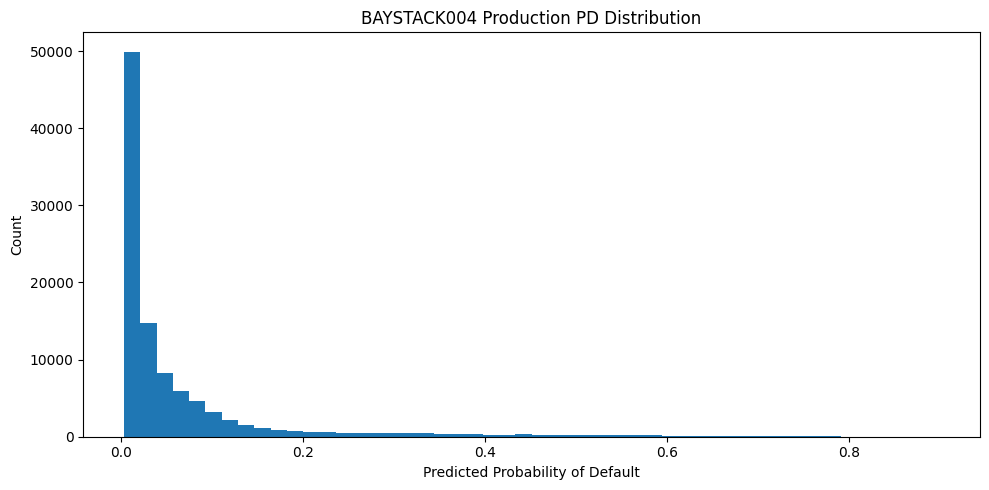

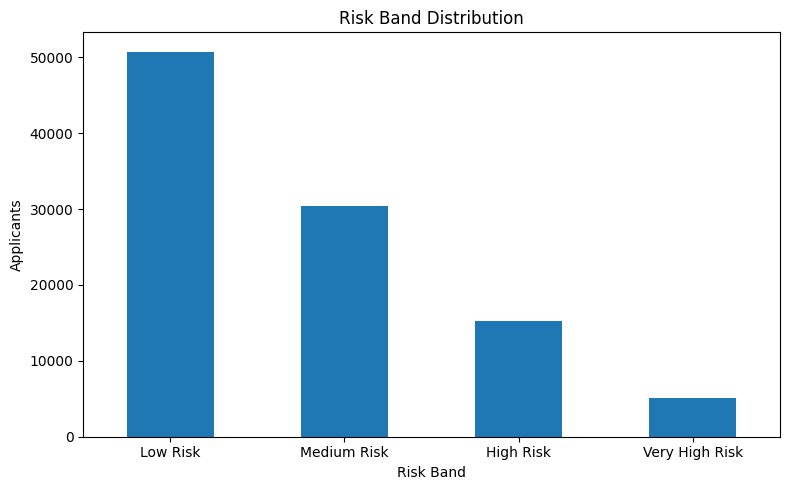

,risk_band,count,min_pd,mean_pd,median_pd,max_pd
0,Low Risk,50751,0.002835,0.011159,0.010564,0.021432
1,Medium Risk,30451,0.021433,0.044829,0.041152,0.083219
2,High Risk,15225,0.083223,0.153096,0.128966,0.321504
3,Very High Risk,5076,0.321512,0.484637,0.464261,0.899225


count    101503.000000
mean         -0.000334
std           0.006581
min          -0.088454
1%           -0.024814
5%           -0.008174
25%          -0.000861
50%          -0.000032
75%           0.000562
95%           0.006119
99%           0.020683
max           0.116703
Name: challenger_delta, dtype: float64

Champion/challenger disagreement analysis saved.


,model_id,model_type,status,scored_rows,mean_pd,median_pd,top_1pct_cutoff,top_5pct_cutoff,top_10pct_cutoff,notes
0,BAYSTACK004,Bayesian Weighted Ensemble,Production Candidate,101503,0.066228,0.021433,0.593021,0.321511,0.164338,Selected after ensemble tournament. Finalists ...


,run_timestamp,notebook_name,rows_scored,production_model_id,models_scored,output_folder,labels_available,evaluation_metrics_computed
0,2026-04-27 23:22:58,05_production_scoring.ipynb,101503,BAYSTACK004,"BAYSTACK004, BAYSTACK002, WASTACK003, XGBSTACK...",/Users/sumanchattopadhyay/Documents/Documents ...,False,False


NOTEBOOK 05 COMPLETE
Production scoring package created.
Output folder: /Users/sumanchattopadhyay/Documents/Documents - Suman’s MacBook Air/Projects/credit-risk-mlops-lab/outputs/production_scoring


In [ ]:


# Ensure scoring output directory exists
SCORING_OUTPUT_DIR = OUTPUT_DIR / "production_scoring"
SCORING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for col in test_finalist_scores.columns:
    scored_test[f"{col}_pd"] = test_finalist_scores[col].values

print("Attached finalist score columns:")
print([c for c in scored_test.columns if c.endswith("_pd")])

run_timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

executive_summary = pd.DataFrame([{
    "run_timestamp": run_timestamp,
    "rows_scored": len(scored_test),
    "production_model_id": production_model_id,
    "mean_pd": scored_test["production_pd"].mean(),
    "median_pd": scored_test["production_pd"].median(),
    "max_pd": scored_test["production_pd"].max(),
    "min_pd": scored_test["production_pd"].min(),
    "top_1pct_cutoff_pd": scored_test["production_pd"].quantile(0.99),
    "top_5pct_cutoff_pd": scored_test["production_pd"].quantile(0.95),
    "top_10pct_cutoff_pd": scored_test["production_pd"].quantile(0.90)
}])

executive_summary.to_csv(
    SCORING_OUTPUT_DIR / "production_scoring_executive_summary.csv",
    index=False
)

display(executive_summary)

action_map = {
    "Low Risk": "Auto Approve",
    "Medium Risk": "Standard Review",
    "High Risk": "Enhanced Review",
    "Very High Risk": "Manual Review Queue"
}

scored_test["recommended_action"] = scored_test["risk_band"].map(action_map)

top_1_n = max(1, int(len(scored_test) * 0.01))
top_5_n = max(1, int(len(scored_test) * 0.05))
top_10_n = max(1, int(len(scored_test) * 0.10))

top_1 = scored_test.nlargest(top_1_n, "production_pd")
top_5 = scored_test.nlargest(top_5_n, "production_pd")
top_10 = scored_test.nlargest(top_10_n, "production_pd")

top_1.to_csv(SCORING_OUTPUT_DIR / "top_1_percent_high_risk.csv", index=False)
top_5.to_csv(SCORING_OUTPUT_DIR / "top_5_percent_high_risk.csv", index=False)
top_10.to_csv(SCORING_OUTPUT_DIR / "top_10_percent_high_risk.csv", index=False)

print("Top risk segment files saved.")

ranking_table = pd.DataFrame({
    "model_id": test_finalist_scores.columns,
    "mean_score": test_finalist_scores.mean().values,
    "median_score": test_finalist_scores.median().values,
    "std_score": test_finalist_scores.std().values,
    "min_score": test_finalist_scores.min().values,
    "p95_score": test_finalist_scores.quantile(0.95).values,
    "p99_score": test_finalist_scores.quantile(0.99).values,
    "max_score": test_finalist_scores.max().values
}).sort_values("mean_score", ascending=False)

ranking_table.to_csv(
    SCORING_OUTPUT_DIR / "finalist_score_distribution_summary.csv",
    index=False
)

display(ranking_table)

plt.figure(figsize=(10, 5))
plt.hist(scored_test["production_pd"], bins=50)
plt.title(f"{production_model_id} Production PD Distribution")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(SCORING_OUTPUT_DIR / "production_pd_distribution.png", dpi=150)
plt.show()

risk_counts = scored_test["risk_band"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
risk_counts.plot(kind="bar")
plt.title("Risk Band Distribution")
plt.xlabel("Risk Band")
plt.ylabel("Applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(SCORING_OUTPUT_DIR / "risk_band_distribution.png", dpi=150)
plt.show()

risk_band_summary = (
    scored_test
    .groupby("risk_band", observed=True)
    .agg(
        count=("applicant_id", "count"),
        min_pd=("production_pd", "min"),
        mean_pd=("production_pd", "mean"),
        median_pd=("production_pd", "median"),
        max_pd=("production_pd", "max")
    )
    .reset_index()
)

risk_band_summary.to_csv(
    SCORING_OUTPUT_DIR / "risk_band_summary.csv",
    index=False
)

display(risk_band_summary)

champion_col = "BAYSTACK004_pd"
challenger_col = "BAYSTACK002_pd"

if champion_col in scored_test.columns and challenger_col in scored_test.columns:

    scored_test["challenger_delta"] = (
        scored_test[champion_col] - scored_test[challenger_col]
    )

    delta_summary = scored_test["challenger_delta"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )

    delta_summary.to_csv(
        SCORING_OUTPUT_DIR / "champion_vs_challenger_delta_summary.csv"
    )

    display(delta_summary)

    largest_disagreements = scored_test.reindex(
        scored_test["challenger_delta"].abs().sort_values(ascending=False).index
    ).head(1000)

    largest_disagreements.to_csv(
        SCORING_OUTPUT_DIR / "champion_vs_challenger_disagreements.csv",
        index=False
    )

    print("Champion/challenger disagreement analysis saved.")

else:
    print(f"Skipping challenger delta: missing {champion_col} or {challenger_col}")

model_card = pd.DataFrame([{
    "model_id": production_model_id,
    "model_type": "Bayesian Weighted Ensemble",
    "status": "Production Candidate",
    "scored_rows": len(scored_test),
    "mean_pd": scored_test["production_pd"].mean(),
    "median_pd": scored_test["production_pd"].median(),
    "top_1pct_cutoff": scored_test["production_pd"].quantile(0.99),
    "top_5pct_cutoff": scored_test["production_pd"].quantile(0.95),
    "top_10pct_cutoff": scored_test["production_pd"].quantile(0.90),
    "notes": "Selected after ensemble tournament. Finalists highly correlated. cs-test.csv has no target labels, so this is production-style scoring rather than performance evaluation."
}])

model_card.to_csv(
    SCORING_OUTPUT_DIR / "production_model_card.csv",
    index=False
)

display(model_card)

batch_metadata = pd.DataFrame([{
    "run_timestamp": run_timestamp,
    "notebook_name": "05_production_scoring.ipynb",
    "rows_scored": len(scored_test),
    "production_model_id": production_model_id,
    "models_scored": ", ".join(test_finalist_scores.columns),
    "output_folder": str(SCORING_OUTPUT_DIR),
    "labels_available": False,
    "evaluation_metrics_computed": False
}])

batch_metadata.to_csv(
    SCORING_OUTPUT_DIR / "batch_run_metadata.csv",
    index=False
)

display(batch_metadata)
scored_test.to_csv(
    SCORING_OUTPUT_DIR / "cs_test_scored_final_output.csv",
    index=False
)

scored_test[
    [
        "applicant_id",
        "production_model_id",
        "production_pd",
        "risk_percentile",
        "risk_band",
        "recommended_action"
    ]
].to_csv(
    SCORING_OUTPUT_DIR / "cs_test_scored_production_minimal.csv",
    index=False
)

# 05_production_scoring.ipynb  
## Executive Summary

This notebook operationalized the full credit risk modeling pipeline by taking the unseen Kaggle `cs-test.csv` population and applying previously trained champion/challenger models in a **production-style batch scoring environment**.

Unlike prior notebooks where models were trained and validated using labeled data, this notebook simulated how a lender would use deployed models in practice:

- ingest new applicant data  
- apply saved preprocessing logic  
- generate probability of default (PD) scores  
- compare champion vs challenger models  
- segment applicants into risk bands  
- create downstream decision outputs  

No models were retrained in this notebook. All artifacts were loaded from prior notebooks.

---

# Why This Notebook Matters

Many projects stop at model training. Real organizations care about:

- Can the model score new data reliably?
- Can outputs be operationalized?
- Can we compare challengers without labels?
- Can business users consume the results?
- Is the deployment process reproducible?

This notebook answers those questions.

---

# Production Champion Selected

## BAYSTACK004  
**Bayesian Weighted Ensemble**

This model was selected after a tournament across:

- weighted average ensembles  
- Bayesian blends  
- XGBoost meta-learners  
- logistic stacking  
- ridge / lasso stacking  
- random forest blenders  
- neural network blenders  
- single model champions  

BAYSTACK004 was selected because it offered:

1. Top-tier validation performance  
2. Strong calibration characteristics  
3. Very high agreement with alternative finalists  
4. Simpler structure than many meta-learners  
5. Easier governance and interpretability  

---

# Interpretability of BAYSTACK004

BAYSTACK004 is a **weighted combination of top-performing base models**, rather than a black-box deep architecture.

That means:

## More Explainable Than Complex Meta-Learners

We can describe score behavior as being influenced by strong underlying models such as:

- LightGBM (nonlinear tree learner)
- CatBoost (categorical-aware gradient boosting)

rather than hidden neural layers or opaque transformations.

## Stable Consensus Model

Correlations between finalists were extremely high (>0.99 in many cases), meaning all top models largely agreed on applicant risk ordering.

That gives confidence that BAYSTACK004 is not a lucky model — it represents consensus signal extraction.

---

# Scoring Population Summary

| Metric | Value |
|---|---:|
| Run Timestamp | 2026-04-27 23:22:58 |
| Applicants Scored | 101,503 |
| Production Model | BAYSTACK004 |
| Mean PD | 6.62% |
| Median PD | 2.14% |
| Minimum PD | 0.28% |
| Maximum PD | 89.92% |
| Top 10% Risk Threshold | 16.43% |
| Top 5% Risk Threshold | 32.15% |
| Top 1% Risk Threshold | 59.30% |

## Interpretation

The portfolio is strongly right-skewed:

- majority of applicants low-to-moderate risk  
- smaller tail of materially risky applicants  
- realistic shape for unsecured consumer credit data

---

# Finalist Model Comparison

| Model | Mean Score | P95 | P99 | Max |
|---|---:|---:|---:|---:|
| LGB002 | 6.72% | 32.82% | 60.80% | 90.47% |
| WASTACK003 | 6.69% | 32.72% | 60.21% | 90.26% |
| BAYSTACK002 | 6.66% | 32.72% | 59.44% | 87.25% |
| BAYSTACK004 | 6.62% | 32.15% | 59.30% | 89.92% |
| XGBSTACK004 | 6.57% | 30.84% | 56.64% | 81.75% |

## Interpretation

All finalists produced highly similar score distributions, reinforcing that the dataset contains stable recoverable risk signal.

This allowed final champion selection to emphasize governance and simplicity.

---

# Risk Band Segmentation

| Risk Band | Count | Mean PD | Median PD |
|---|---:|---:|---:|
| Low Risk | 50,751 | 1.12% | 1.06% |
| Medium Risk | 30,451 | 4.48% | 4.12% |
| High Risk | 15,225 | 15.31% | 12.90% |
| Very High Risk | 5,076 | 48.46% | 46.43% |

## Operational Interpretation

### Low Risk
Likely automated approvals / fastest processing.

### Medium Risk
Standard underwriting review.

### High Risk
Enhanced checks, pricing adjustments, reduced limits.

### Very High Risk
Manual review queue / decline strategy / collections sensitivity.

---

# Champion vs Challenger Analysis

Compared:

- Champion: BAYSTACK004  
- Challenger: BAYSTACK002

Delta summary:

- Mean difference: -0.000334
- Median difference: near zero
- 95% of differences within ±0.006

## Interpretation

These models are economically almost identical in most cases.

That means the final champion decision is driven more by governance preferences than raw score differences.

This is common in mature model risk management environments.

---

# What We Did NOT Do Here

Because `cs-test.csv` has **no target labels**, we did **not** compute:

- AUC
- KS
- Accuracy
- LogLoss vs actuals
- Precision / Recall

Those require known outcomes.

This notebook is **deployment scoring**, not retrospective validation.

---

# Did We Do Distribution / Drift Analysis?

## Short Answer: Partial Only

### Yes — Distribution Analysis Performed

We reviewed:

- PD score histogram
- risk band counts
- challenger score deltas
- finalist score distributions

### No — Full Variable Drift Analysis Not Yet Performed

We did **not yet** compare training vs scoring population for raw features such as:

- age  
- utilization  
- debt ratio  
- delinquency counts  
- income  
- dependents  

Nor did we compute:

- PSI (Population Stability Index)
- CSI
- feature mean shifts
- missing rate shifts
- bin migration analysis

---

# Strong Recommendation: Notebook 06

## `06_model_monitoring.ipynb`

Should include:

### Data Drift

- PSI by variable
- Missingness shift
- Feature distribution overlays

### Model Drift

- Score PSI
- Risk band migration
- Champion vs challenger divergence

### Governance

- Alerts if PSI > thresholds
- Monitoring dashboard outputs

This would elevate the project to real enterprise-grade deployment.

---

# Final Conclusion

This notebook completed the transition from **model development** to **production-ready scoring operations**.

The project now demonstrates:

- model development  
- ensemble selection  
- artifact management  
- production scoring  
- challenger governance  
- business segmentation  
- deployment readiness  

This is substantially stronger than a standard Kaggle notebook and resembles real-world banking analytics workflow.